In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img = cv2.imread(r"C:\Users\Hp\Pictures\OpenCVSamples\Color.png")
hsv = cv2.cvtColor(img , cv2.COLOR_BGR2HSV)

You're basically telling OpenCV:

"I want pixels whose HSV values fall within this range."

You are defining:
```text
        Lower limit              Upper limit
             ↓                       ↓
       [60(H), 35(S), 140(V)]          [180, 255, 255]
             │                       │
             └─────────┬─────────────┘
                       ↓
                  BLUE RANGE

```text 
we know that in color wheel blue comes around which particular range         
         
          0 / 179
            RED
             │
             │
   150 ──────┼────── 30
    RED      │      YELLOW
             │
    120 ─────┼────── 60
     BLUE    │      GREEN
             │
             90
            CYAN

In [18]:
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

We convert BGR → HSV to make color detection easier, but we apply the resulting mask to the original BGR image so that we retain the original pixel colors.

In [19]:
mask = cv2.inRange(hsv,lower_blue,upper_blue)
result = cv2.bitwise_and(img,img,mask=mask)

In [20]:
result_rgb = cv2.cvtColor(result,cv2.COLOR_BGR2RGB)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

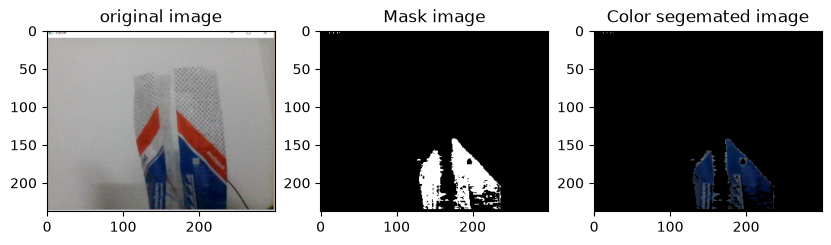

In [22]:
plt.figure(figsize=(10,10))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title('original image')

plt.subplot(132)
plt.imshow(mask,cmap='gray')
plt.title('Mask image')

plt.subplot(133)
plt.imshow(result_rgb)
plt.title('Color segemated image')

plt.show()

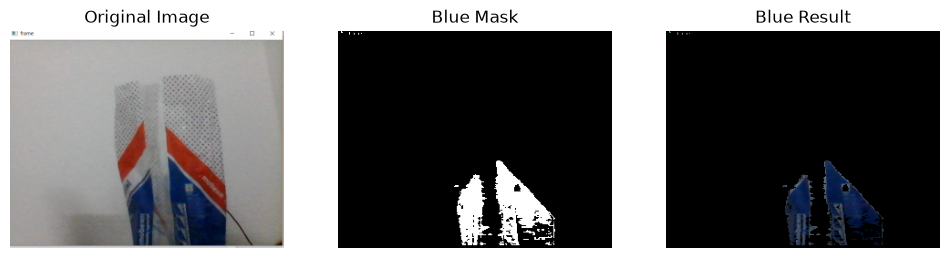

In [ ]:
# # Convert BGR → HSV
# hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# # Blue range
# lower_blue = np.array([90, 50, 50])
# upper_blue = np.array([130, 255, 255])

# # Create mask
# mask = cv2.inRange(hsv, lower_blue, upper_blue)

# # Keep only blue region
# result = cv2.bitwise_and(img, img, mask=mask)

# # Convert BGR → RGB for matplotlib
# image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# # Display
# plt.figure(figsize=(12, 4))

# plt.subplot(1, 3, 1)
# plt.imshow(image_rgb)
# plt.title("Original Image")
# plt.axis("off")

# plt.subplot(1, 3, 2)
# plt.imshow(mask, cmap="gray")
# plt.title("Blue Mask")
# plt.axis("off")

# plt.subplot(1, 3, 3)
# plt.imshow(result_rgb)
# plt.title("Blue Result")
# plt.axis("off")

# plt.show()